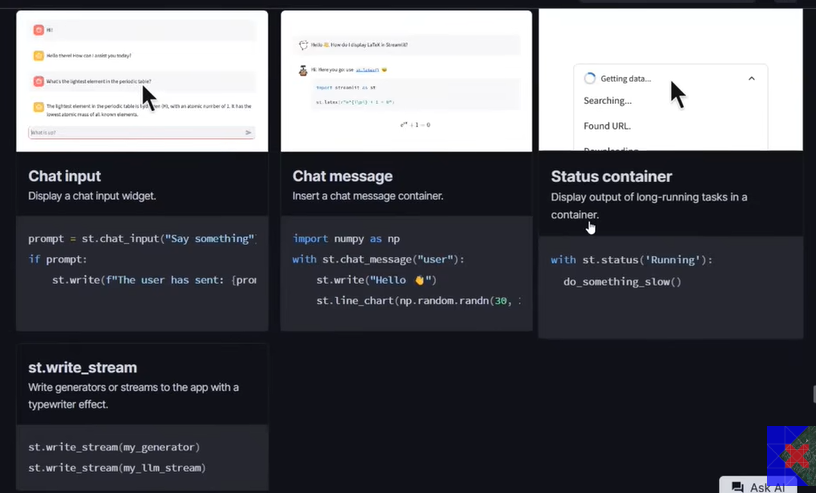

```
in stream lit if we go to chat feature we will look that various option
- chat input
- chat messgae
- stream continer  
- st. wrtire strem   this provide typ writing effect
we will now use st.write this write stream will handel typ writing effect
st.text ❌
st.write_stream ✅

```
this write stream need a genrator to work
----------
st.write_stream(
genrator
)
---------
st.write_stream(
  chatbot.stream  >>> we will call stream function from backend
)
------
this strem messgae will give messgae chnck and metaga data
so we need messga_chunk.content for every message and meta data

we will add this to session_state >> dictionary that stream provide

```
so we need only conten from stream( which is having messgae chunk and meta data ) hence

messgae_chunk.content for messgae_chaunk,metadata in chotbot.stream(

  3 parameter
)
)
as we do for lopp to take out the content okay


In [9]:
!pip install streamlit pyngrok -q
!pip install -q langgraph langchain langchain-core langchain-groq python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 36.4 MB/s eta 0:00:00


In [12]:
%%writefile app.py
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage
import streamlit as st

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key="----"
)
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

checkpointer = InMemorySaver()
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)
chatbot = graph.compile(checkpointer=checkpointer)

CONFIG = {'configurable': {'thread_id': 'thread-1'}}

if 'message_history' not in st.session_state:
    st.session_state['message_history'] = []

for message in st.session_state['message_history']:
    with st.chat_message(message['role']):
        st.text(message['content'])

user_input = st.chat_input('Type here')

if user_input:

    # first add the message to message_history
    st.session_state['message_history'].append({'role': 'user', 'content': user_input})
    with st.chat_message('user'):
        st.text(user_input)

    # first add the message to message_history
    with st.chat_message('assistant'):

        ai_message = st.write_stream(
            message_chunk.content for message_chunk, metadata in chatbot.stream(
                {'messages': [HumanMessage(content=user_input)]},
                config= {'configurable': {'thread_id': 'thread-1'}},
                stream_mode= 'messages'
            )
        )

    st.session_state['message_history'].append({'role': 'assistant', 'content': ai_message})

Overwriting app.py


In [13]:
!streamlit run app.py &>/content/logs.txt &


from google.colab import userdata
from pyngrok import ngrok
import time

pyngrok_token = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(pyngrok_token)

time.sleep(3)
public_url = ngrok.connect(addr=8501)
print(public_url)


NgrokTunnel: "https://thrower-curvature-rigid.ngrok-free.dev" -> "http://localhost:8501"


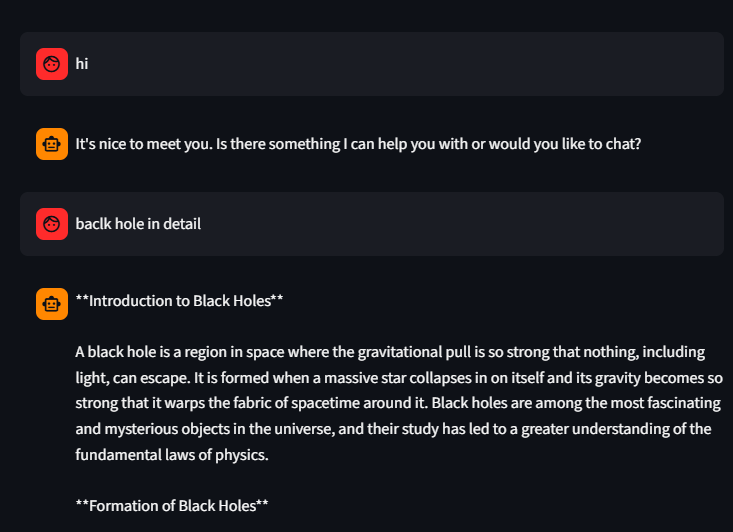